In [5]:
import urllib.request

urllib.request.urlretrieve(
    'https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEXUSAL',
    '/content/DEXUSAL.csv'
)
print('Dataset descargado correctamente.')

Dataset descargado correctamente.


In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/DEXUSAL.csv')
df.head()

,observation_date,DEXUSAL
0,1971-01-04,1.1127
1,1971-01-05,1.1132
2,1971-01-06,1.1140
3,1971-01-07,1.1138
4,1971-01-08,1.1124


In [7]:
# Renombrar columnas para claridad
df.columns = ['Date', 'Exchange rate']

# Convertir tipos
df['Date'] = pd.to_datetime(df['Date'])
df['Exchange rate'] = pd.to_numeric(df['Exchange rate'], errors='coerce')

# Ordenar y eliminar nulos
df = df.sort_values('Date').dropna().reset_index(drop=True)

print(f"Rango de fechas: {df['Date'].min()} → {df['Date'].max()}")
print(f"Total de registros: {len(df)}")
df.head()

Rango de fechas: 1971-01-04 00:00:00 → 2026-03-13 00:00:00
Total de registros: 13833


,Date,Exchange rate
0,1971-01-04,1.1127
1,1971-01-05,1.1132
2,1971-01-06,1.1140
3,1971-01-07,1.1138
4,1971-01-08,1.1124


In [8]:
from sklearn.preprocessing import MinMaxScaler

serie = df['Exchange rate'].values
serie = serie[np.isfinite(serie)]

scaler = MinMaxScaler()
serie_scaled = scaler.fit_transform(serie.reshape(-1, 1))

print(f"Valores infinitos: {np.isinf(serie).sum()}")
print(f"Longitud de la serie: {len(serie_scaled)}")

Valores infinitos: 0
Longitud de la serie: 13833


In [9]:
def create_dataset(series, n_steps):
    X, y = [], []
    for i in range(len(series) - n_steps):
        X.append(series[i:i + n_steps])
        y.append(series[i + n_steps])
    return np.array(X), np.array(y)

n_steps = 30  # ventana de 30 días

X, y = create_dataset(serie_scaled, n_steps)
print(f"Shape X: {X.shape}, Shape y: {y.shape}")

Shape X: (13803, 30, 1), Shape y: (13803, 1)


In [10]:
split = int(0.7 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape para LSTM: (samples, timesteps, features)
X_train_rnn = X_train.reshape(X_train.shape[0], n_steps, 1)
X_test_rnn  = X_test.reshape(X_test.shape[0],  n_steps, 1)

print(f"Train: {X_train_rnn.shape} | Test: {X_test_rnn.shape}")

Train: (9662, 30, 1) | Test: (4141, 30, 1)


In [11]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=50,
                            num_layers=2, batch_first=True)
        self.fc = nn.Linear(50, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # último timestep
        return self.fc(out)

In [12]:
def train_rnn(model, X_train, y_train, X_test, y_test, epochs=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    train_losses, test_losses = [], []

    for epoch in range(epochs):
        model.train()
        X_t = torch.tensor(X_train, dtype=torch.float32)
        y_t = torch.tensor(y_train, dtype=torch.float32)

        optimizer.zero_grad()
        pred = model(X_t)
        loss = criterion(pred, y_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            X_val = torch.tensor(X_test, dtype=torch.float32)
            y_val = torch.tensor(y_test, dtype=torch.float32)
            val_loss = criterion(model(X_val), y_val)

        train_losses.append(loss.item())
        test_losses.append(val_loss.item())
        print(f"Epoch {epoch+1:2d} | Loss: {loss.item():.5f} | Val: {val_loss.item():.5f}")

    return train_losses, test_losses

In [13]:
lstm_model = LSTMModel()

train_loss_lstm, test_loss_lstm = train_rnn(
    lstm_model, X_train_rnn, y_train, X_test_rnn, y_test, epochs=20
)

Epoch  1 | Loss: 0.15502 | Val: 0.05911
Epoch  2 | Loss: 0.13860 | Val: 0.04853
Epoch  3 | Loss: 0.12339 | Val: 0.03923
Epoch  4 | Loss: 0.10931 | Val: 0.03125
Epoch  5 | Loss: 0.09638 | Val: 0.02472
Epoch  6 | Loss: 0.08468 | Val: 0.01986
Epoch  7 | Loss: 0.07435 | Val: 0.01699
Epoch  8 | Loss: 0.06566 | Val: 0.01658
Epoch  9 | Loss: 0.05903 | Val: 0.01916
Epoch 10 | Loss: 0.05499 | Val: 0.02507
Epoch 11 | Loss: 0.05409 | Val: 0.03367
Epoch 12 | Loss: 0.05622 | Val: 0.04219
Epoch 13 | Loss: 0.05972 | Val: 0.04726
Epoch 14 | Loss: 0.06201 | Val: 0.04778
Epoch 15 | Loss: 0.06188 | Val: 0.04476
Epoch 16 | Loss: 0.05980 | Val: 0.03984
Epoch 17 | Loss: 0.05685 | Val: 0.03445
Epoch 18 | Loss: 0.05394 | Val: 0.02948
Epoch 19 | Loss: 0.05160 | Val: 0.02536
Epoch 20 | Loss: 0.04999 | Val: 0.02216


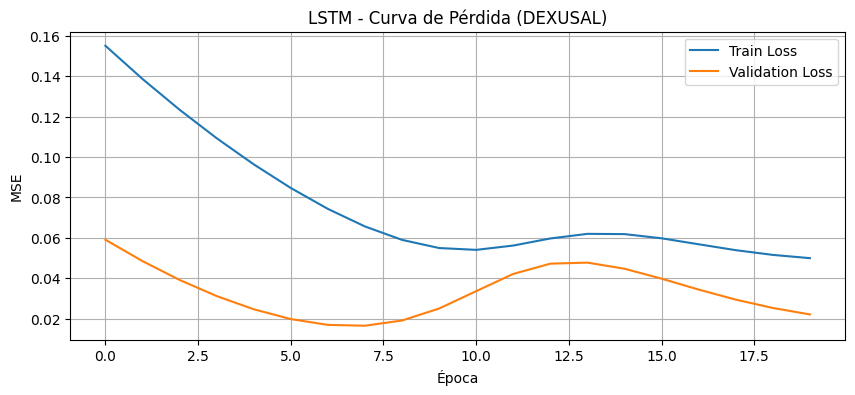

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_loss_lstm, label='Train Loss')
plt.plot(test_loss_lstm, label='Validation Loss')
plt.legend()
plt.title('LSTM - Curva de Pérdida (DEXUSAL)')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.grid(True)
plt.show()

In [15]:
lstm_model.eval()

with torch.no_grad():
    preds_lstm = lstm_model(
        torch.tensor(X_test_rnn, dtype=torch.float32)
    ).numpy()

# Desnormalizar
y_test_inv    = scaler.inverse_transform(y_test)
preds_inv     = scaler.inverse_transform(preds_lstm)

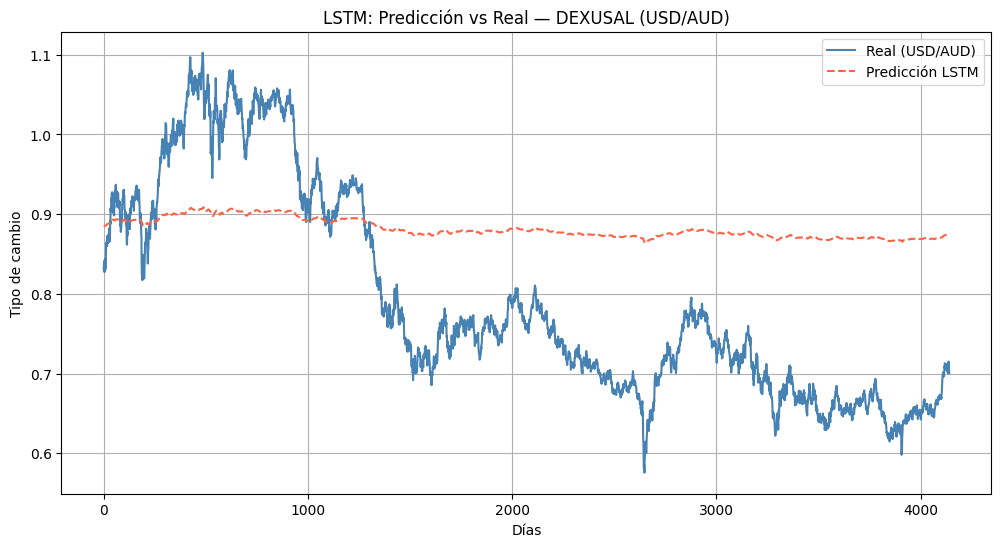

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv,  label='Real (USD/AUD)', color='steelblue')
plt.plot(preds_inv,   label='Predicción LSTM', color='tomato', linestyle='--')
plt.legend()
plt.title('LSTM: Predicción vs Real — DEXUSAL (USD/AUD)')
plt.xlabel('Días')
plt.ylabel('Tipo de cambio')
plt.grid(True)
plt.show()